# Mezcla de gaussianas (GMM) sobre el espacio latente del autoencoder

Réplica de `hc_autoencoder.ipynb` cambiando el algoritmo de clustering: la misma
reducción con autoencoder (misma grilla, misma selección por MSE de validación), pero
sobre el espacio latente se ajusta una **mezcla de gaussianas (GMM)** en lugar del
clustering jerárquico de Ward.

La motivación es la misma que en `gmm_clustering.ipynb`: un artículo puede pertenecer a
más de un tema a la vez, y la GMM entrega una **probabilidad de pertenencia a cada
componente** en lugar de una etiqueta única. Aquí, además, el escenario le es favorable:
los latentes tienen 16–64 dims, así que la GMM se ajusta **directamente y sin PCA
previa** — no existe el factor de confusión de la reducción intermedia de
`gmm_clustering.ipynb`.

El pipeline de autoencoder (arquitectura, grilla y selección) es idéntico al de
`hc_autoencoder.ipynb`, de modo que la única diferencia entre ambos notebooks sea el
algoritmo de clustering. La selección de la GMM usa **BIC** (covarianzas `full`, `diag`,
`tied`; k = 2…15) y las métricas de silhouette/CH/DB se calculan sobre el espacio
latente L2-normalizado, igual que en `hc_autoencoder.ipynb`. La sección de subclusters
se reemplaza por el **análisis de pertenencias blandas**.


In [ ]:
%cd "/home/pherrera/projects/clustering_n_rag_u_index/notebooks"
%pwd

/home/pherrera/projects/clustering_n_rag_u_index/notebooks


'/home/pherrera/projects/clustering_n_rag_u_index/notebooks'

In [2]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn

sys.path.insert(0, str(Path.cwd().parent))

PALETA = ["#2a78d6", "#008300", "#e87ba4", "#c9761a", "#7b5ea7", "#c0392b"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} — dispositivo: {DEVICE}")


def rejilla(n: int, ancho: float = 5.3, alto: float = 4.5, ncols: int = 3):
    """Rejilla de `n` paneles en `ncols` columnas; oculta los ejes sobrantes.

    Con seis técnicas una sola fila haría figuras de ~32 pulgadas de ancho,
    ilegibles al renderizar; el envoltorio en filas mantiene el tamaño por panel.
    """
    nfilas = -(-n // ncols)
    fig, axes = plt.subplots(nfilas, ncols, figsize=(ancho * ncols, alto * nfilas))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes[:n]


PyTorch 2.3.0+cu121 — dispositivo: cuda


## Reproducción de la submuestra del EDA

Se replica exactamente la submuestra estratificada de ~1,500 artículos del EDA
(misma limpieza, mismos estratos año × periódico, mismo `random_state`) y se verifica
contra los `id_articulo` guardados en `data/embeddings/muestra_ids.npy` para garantizar
que los embeddings cacheados corresponden a estos textos.


In [3]:
import re
from math import ceil

data = pd.read_csv("../data/raw/stratified_sample_2019_2026.csv")
data.drop(columns=["anio", "id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = data["fecha"].dt.year


def norm_text(text: str) -> str:
    """Normaliza un texto: minúsculas y colapso de espacios en blanco."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["texto_norm"] = data["texto"].map(norm_text)

N_MUESTRA = 1500
estratos = data.groupby(["nombre_periodico", "anio"])
cuota = ceil(N_MUESTRA / estratos.ngroups)
muestra = pd.concat(
    [g.sample(min(len(g), cuota), random_state=RANDOM_STATE) for _, g in estratos]
).sort_values(["anio", "nombre_periodico", "id_articulo"]).reset_index(drop=True)

textos_emb = (muestra["titulo"].fillna("").map(norm_text) + ". "
              + muestra["texto_norm"]).str.slice(0, 2000).tolist()

EMB_DIR = Path("../data/embeddings")
ids_muestra = muestra["id_articulo"].to_numpy()
assert np.array_equal(np.load(EMB_DIR / "muestra_ids.npy"), ids_muestra), \
    "La submuestra no coincide con la usada en el EDA: recalcular embeddings en eda.ipynb"
print(f"Submuestra reproducida: {len(muestra)} artículos — ids verificados contra el caché")


Submuestra reproducida: 1512 artículos — ids verificados contra el caché


## Carga de embeddings originales (entradas del autoencoder)

MiniLM y BGE-M3 se cargan del caché generado por `eda.ipynb`; TF-IDF se recalcula con
los mismos hiperparámetros y se reduce con `TruncatedSVD` a 50 componentes, igual que en
`hc_clustering.ipynb`. Todos se L2-normalizan: estos vectores son la **entrada** que el
autoencoder aprende a reconstruir.


In [4]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vectorizador = TfidfVectorizer(max_features=50_000, min_df=3, max_df=0.6, sublinear_tf=True)
emb_tfidf_sparse = vectorizador.fit_transform(textos_emb)
emb_tfidf = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(emb_tfidf_sparse)

emb_st = np.load(EMB_DIR / "minilm_multilingual.npy")
emb_bge = np.load(EMB_DIR / "bge_m3.npy")
emb_beto = np.load(EMB_DIR / "beto.npy")
emb_nemotron = np.load(EMB_DIR / "nemotron.npy")

N_COMP = 128


def whitening(emb: np.ndarray, n_comp: int = N_COMP) -> np.ndarray:
    """Centra y descorrelaciona `emb`, reteniendo las `n_comp` direcciones de mayor varianza.

    Misma transformación que en `hc_clustering.ipynb`, para que la comparación
    embedding original vs. latente sea sobre las mismas seis representaciones.
    """
    mu = emb.mean(axis=0)
    centrado = emb - mu
    # SVD de la covarianza: U son las direcciones principales, s sus varianzas.
    U, s, _ = np.linalg.svd(np.cov(centrado, rowvar=False))
    W = U[:, :n_comp] / np.sqrt(s[:n_comp])  # Sigma^(-1/2) truncada
    return centrado @ W


embeddings = {
    "TF-IDF (SVD-50)": normalize(emb_tfidf),
    "MiniLM multilingüe": normalize(emb_st),
    "BGE-M3": normalize(emb_bge),
    "BETO": normalize(emb_beto),
    "BETO (whitened)": normalize(whitening(emb_beto)),
    "Nemotron VL": normalize(emb_nemotron),
}
for nombre, emb in embeddings.items():
    print(f"{nombre}: {emb.shape}")


TF-IDF (SVD-50): (1512, 50)
MiniLM multilingüe: (1512, 384)
BGE-M3: (1512, 1024)
BETO: (1512, 768)
BETO (whitened): (1512, 128)
Nemotron VL: (1512, 2048)


## Autoencoder: arquitectura y búsqueda de configuraciones

Autoencoder MLP **simétrico** (decoder espejo del encoder) con activaciones ReLU,
entrenado para minimizar el MSE de reconstrucción con Adam y *early stopping* sobre un
conjunto de validación (15% de la muestra, partición fija con `RANDOM_STATE`).

Grilla de pruebas por técnica:

- **Dimensión latente:** 16, 32, 64 (se omiten latentes ≥ dimensión de entrada).
- **Capas ocultas del encoder:** ninguna (`entrada → latente`), una (`entrada → 128 → latente`)
  y dos (`entrada → 256 → 128 → latente`).

Para cada técnica se conserva el autoencoder con **menor MSE de validación** y su espacio
latente reemplaza al embedding original en el resto del análisis.


In [5]:
class Autoencoder(nn.Module):
    """Autoencoder MLP simétrico: decoder espejo del encoder, activaciones ReLU."""

    def __init__(self, dim_entrada: int, dims_ocultas: list[int], dim_latente: int):
        super().__init__()
        dims_enc = [dim_entrada, *dims_ocultas]
        capas_enc = []
        for d_in, d_out in zip(dims_enc, dims_enc[1:]):
            capas_enc += [nn.Linear(d_in, d_out), nn.ReLU()]
        capas_enc.append(nn.Linear(dims_enc[-1], dim_latente))
        self.encoder = nn.Sequential(*capas_enc)

        dims_dec = [dim_latente, *reversed(dims_ocultas)]
        capas_dec = []
        for d_in, d_out in zip(dims_dec, dims_dec[1:]):
            capas_dec += [nn.Linear(d_in, d_out), nn.ReLU()]
        capas_dec.append(nn.Linear(dims_dec[-1], dim_entrada))
        self.decoder = nn.Sequential(*capas_dec)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


def entrenar_autoencoder(X: np.ndarray, dims_ocultas: list[int], dim_latente: int,
                         epocas: int = 500, paciencia: int = 40,
                         lr: float = 1e-3, batch: int = 128):
    """Entrena un autoencoder y devuelve (modelo, mse_validacion).

    Partición fija 85/15 train/validación; early stopping por MSE de validación,
    restaurando los pesos del mejor punto.
    """
    torch.manual_seed(RANDOM_STATE)
    rng = np.random.default_rng(RANDOM_STATE)
    orden = rng.permutation(len(X))
    n_val = int(len(X) * 0.15)
    X_val = torch.tensor(X[orden[:n_val]], dtype=torch.float32, device=DEVICE)
    X_tr = torch.tensor(X[orden[n_val:]], dtype=torch.float32, device=DEVICE)

    modelo = Autoencoder(X.shape[1], dims_ocultas, dim_latente).to(DEVICE)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    perdida = nn.MSELoss()

    mejor_val, mejor_estado, sin_mejora = float("inf"), None, 0
    for _ in range(epocas):
        modelo.train()
        barajado = torch.randperm(len(X_tr), device=DEVICE)
        for i in range(0, len(X_tr), batch):
            lote = X_tr[barajado[i:i + batch]]
            optimizador.zero_grad()
            error = perdida(modelo(lote), lote)
            error.backward()
            optimizador.step()
        modelo.eval()
        with torch.no_grad():
            mse_val = perdida(modelo(X_val), X_val).item()
        if mse_val < mejor_val - 1e-7:
            mejor_val, sin_mejora = mse_val, 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break
    modelo.load_state_dict(mejor_estado)
    modelo.eval()
    return modelo, mejor_val


In [6]:
DIMS_LATENTES = [16, 32, 64]
ARQUITECTURAS = {
    "sin ocultas": [],
    "1 oculta (128)": [128],
    "2 ocultas (256→128)": [256, 128],
}

filas, modelos_ae = [], {}
for nombre, emb in embeddings.items():
    for etiqueta_arq, dims_ocultas in ARQUITECTURAS.items():
        for dim_latente in DIMS_LATENTES:
            if dim_latente >= emb.shape[1]:
                continue
            modelo, mse_val = entrenar_autoencoder(emb, dims_ocultas, dim_latente)
            modelos_ae[(nombre, etiqueta_arq, dim_latente)] = modelo
            filas.append({"tecnica": nombre, "arquitectura": etiqueta_arq,
                          "dim_latente": dim_latente, "mse_val": mse_val})
            print(f"{nombre} | {etiqueta_arq} | latente={dim_latente}: "
                  f"MSE val = {mse_val:.6f}")

pruebas_ae = pd.DataFrame(filas)


TF-IDF (SVD-50) | sin ocultas | latente=16: MSE val = 0.009111
TF-IDF (SVD-50) | sin ocultas | latente=32: MSE val = 0.005021
TF-IDF (SVD-50) | 1 oculta (128) | latente=16: MSE val = 0.006246
TF-IDF (SVD-50) | 1 oculta (128) | latente=32: MSE val = 0.002589
TF-IDF (SVD-50) | 2 ocultas (256→128) | latente=16: MSE val = 0.006241
TF-IDF (SVD-50) | 2 ocultas (256→128) | latente=32: MSE val = 0.002906
MiniLM multilingüe | sin ocultas | latente=16: MSE val = 0.001221
MiniLM multilingüe | sin ocultas | latente=32: MSE val = 0.000885
MiniLM multilingüe | sin ocultas | latente=64: MSE val = 0.000519
MiniLM multilingüe | 1 oculta (128) | latente=16: MSE val = 0.001160
MiniLM multilingüe | 1 oculta (128) | latente=32: MSE val = 0.000879
MiniLM multilingüe | 1 oculta (128) | latente=64: MSE val = 0.000542
MiniLM multilingüe | 2 ocultas (256→128) | latente=16: MSE val = 0.001139
MiniLM multilingüe | 2 ocultas (256→128) | latente=32: MSE val = 0.000895
MiniLM multilingüe | 2 ocultas (256→128) | late

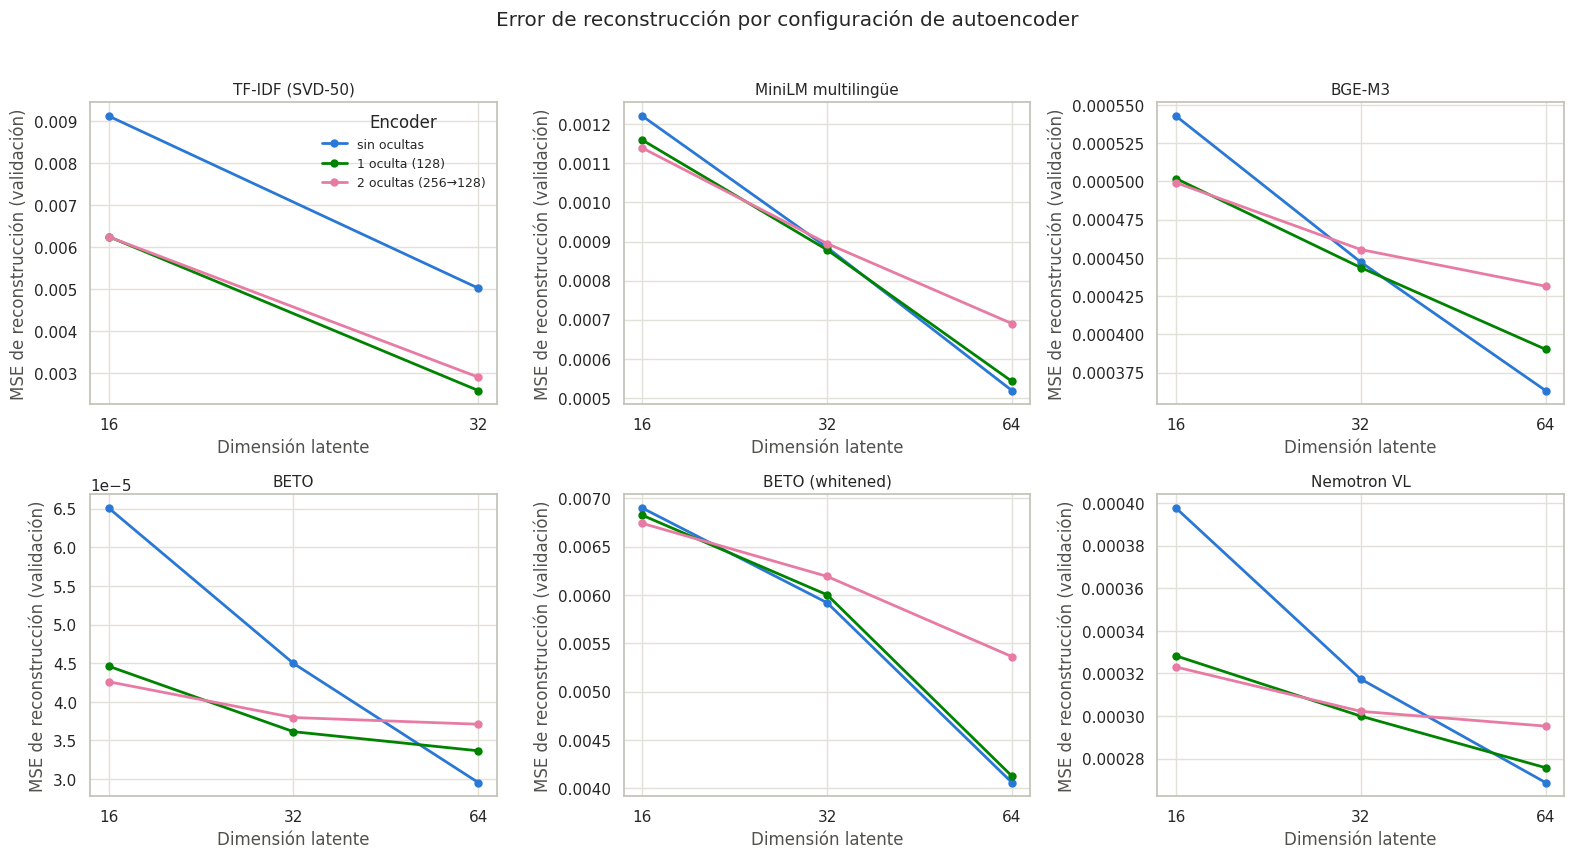

In [7]:
fig, axes = rejilla(len(embeddings), alto=4.2)
for ax, nombre in zip(axes, embeddings):
    sub = pruebas_ae[pruebas_ae["tecnica"] == nombre]
    for color, (etiqueta_arq, g) in zip(PALETA, sub.groupby("arquitectura", sort=False)):
        ax.plot(g["dim_latente"], g["mse_val"], marker="o", markersize=5,
                linewidth=2, color=color, label=etiqueta_arq)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Dimensión latente")
    ax.set_ylabel("MSE de reconstrucción (validación)")
    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted(sub["dim_latente"].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].legend(frameon=False, fontsize=9, title="Encoder")
plt.suptitle("Error de reconstrucción por configuración de autoencoder", y=1.02)
plt.tight_layout()
plt.show()


## Selección del mejor autoencoder y proyección al espacio latente

Se toma, por técnica, la configuración con menor MSE de validación; el encoder de ese
modelo proyecta **toda** la muestra al espacio latente y el resultado se L2-normaliza
(igual que los embeddings originales) para que Ward opere sobre distancias comparables
a coseno.


In [ ]:
mejores_ae = (pruebas_ae.loc[pruebas_ae.groupby("tecnica", sort=False)["mse_val"].idxmin()]
              .set_index("tecnica"))
display(mejores_ae.round(6))

embeddings_lat = {}
for nombre, fila in mejores_ae.iterrows():
    modelo = modelos_ae[(nombre, fila["arquitectura"], fila["dim_latente"])]
    with torch.no_grad():
        latente = modelo.encoder(
            torch.tensor(embeddings[nombre], dtype=torch.float32, device=DEVICE)
        ).cpu().numpy()
    embeddings_lat[nombre] = normalize(latente)
    print(f"{nombre}: {embeddings[nombre].shape[1]} dims → latente {latente.shape[1]} "
          f"({fila['arquitectura']}, MSE val {fila['mse_val']:.6f})")


,arquitectura,dim_latente,mse_val
tecnica,,,
TF-IDF (SVD-50),1 oculta (128),32,0.002589
MiniLM multilingüe,sin ocultas,64,0.000519
BGE-M3,sin ocultas,64,0.000363
BETO,sin ocultas,64,0.000030
BETO (whitened),sin ocultas,64,0.004058
Nemotron VL,sin ocultas,64,0.000269


TF-IDF (SVD-50): 50 dims → latente 32 (1 oculta (128), MSE val 0.002589)
MiniLM multilingüe: 384 dims → latente 64 (sin ocultas, MSE val 0.000519)
BGE-M3: 1024 dims → latente 64 (sin ocultas, MSE val 0.000363)
BETO: 768 dims → latente 64 (sin ocultas, MSE val 0.000030)
BETO (whitened): 128 dims → latente 64 (sin ocultas, MSE val 0.004058)
Nemotron VL: 2048 dims → latente 64 (sin ocultas, MSE val 0.000269)


## Espacio de entrada de la GMM

Los latentes del autoencoder ya tienen ≤ 64 dims, así que la GMM se ajusta directamente
sobre ellos, sin PCA previa — a diferencia de `gmm_clustering.ipynb`, donde los
embeddings originales (hasta 2048 dims) obligan a reducir antes de estimar covarianzas.


In [ ]:
X_gmm = embeddings_lat
for nombre, X in X_gmm.items():
    print(f"{nombre}: GMM sobre latente de {X.shape[1]} dims")


TF-IDF (SVD-50): GMM sobre latente de 32 dims
MiniLM multilingüe: GMM sobre latente de 64 dims
BGE-M3: GMM sobre latente de 64 dims
BETO: GMM sobre latente de 64 dims
BETO (whitened): GMM sobre latente de 64 dims
Nemotron VL: GMM sobre latente de 64 dims


## Ajuste de la GMM y selección de modelo (BIC)

Para cada técnica se ajustan mezclas con k = 2…15 componentes y tres estructuras de
covarianza (`full`, `diag`, `tied`), con 3 reinicios de EM por configuración. El **BIC**
(↓ mejor) penaliza el número de parámetros, así que permite comparar covarianzas de
distinta complejidad sin favorecer mecánicamente a la más flexible. Por técnica se fija
la covarianza del modelo con menor BIC global y, con ella, se guardan las
responsabilidades y las etiquetas duras para todo el rango de k — el equivalente de los
cortes del dendrograma en HC.


In [10]:
from sklearn.mixture import GaussianMixture

RANGO_K = range(2, 16)
COV_TYPES = ["full", "diag", "tied"]

filas, gmms = [], {}
for nombre, X in X_gmm.items():
    for cov in COV_TYPES:
        for k in RANGO_K:
            gmm = GaussianMixture(n_components=k, covariance_type=cov, n_init=3,
                                  reg_covar=1e-6, random_state=RANDOM_STATE)
            gmm.fit(X)
            gmms[(nombre, cov, k)] = gmm
            filas.append({"tecnica": nombre, "covarianza": cov, "k": k,
                          "bic": gmm.bic(X), "aic": gmm.aic(X),
                          "convergio": gmm.converged_})
    print(f"{nombre}: {len(COV_TYPES) * len(RANGO_K)} modelos ajustados")

modelos_gmm = pd.DataFrame(filas)


TF-IDF (SVD-50): 42 modelos ajustados
MiniLM multilingüe: 42 modelos ajustados
BGE-M3: 42 modelos ajustados
BETO: 42 modelos ajustados
BETO (whitened): 42 modelos ajustados
Nemotron VL: 42 modelos ajustados


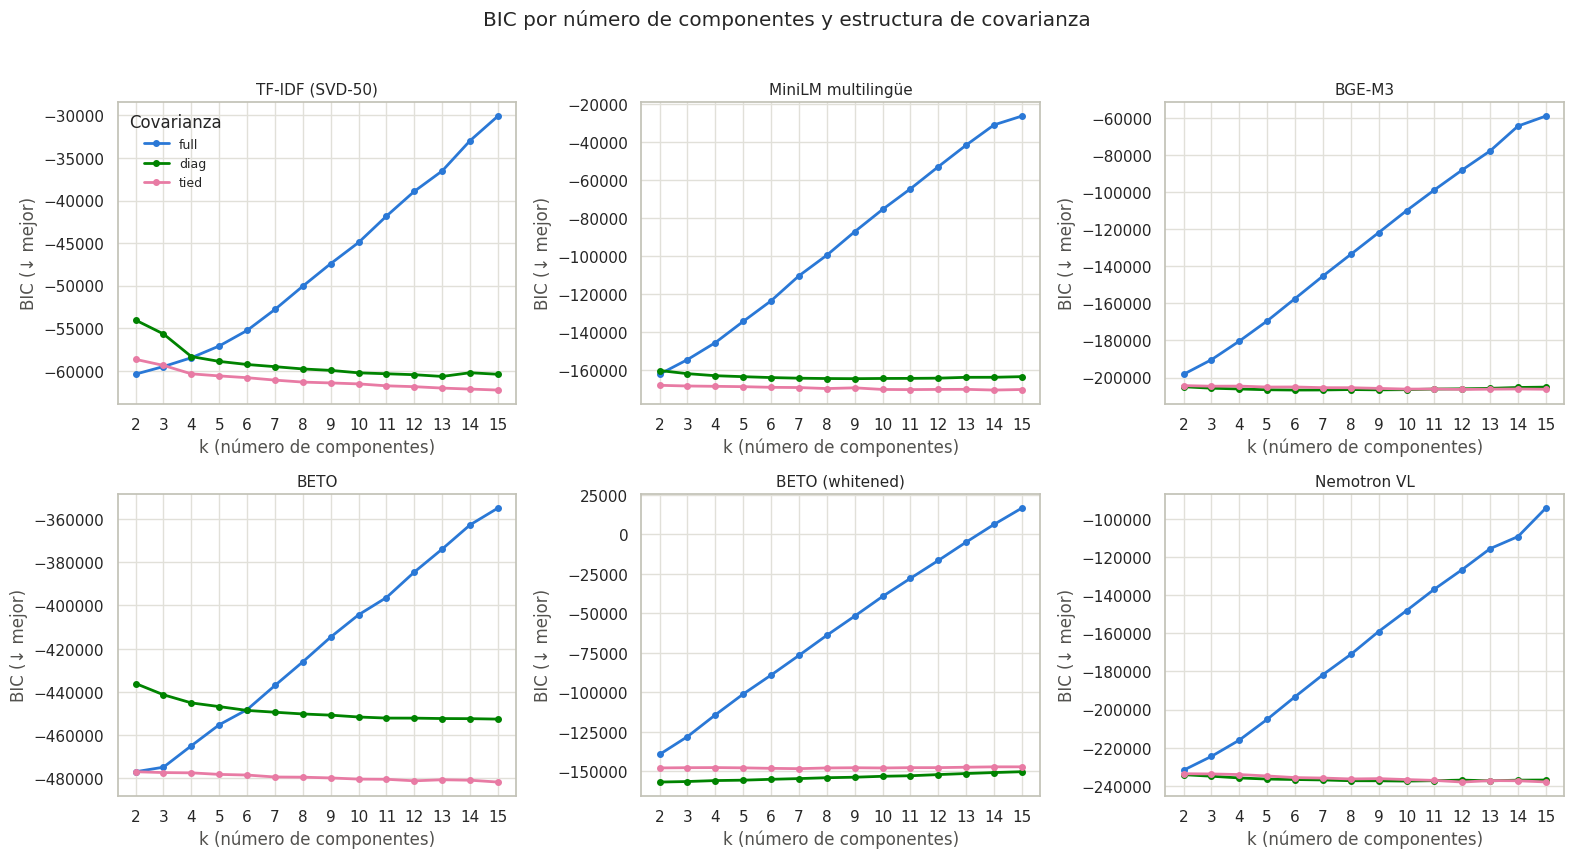

In [11]:
fig, axes = rejilla(len(X_gmm), alto=4.2)
for ax, nombre in zip(axes, X_gmm):
    sub = modelos_gmm[modelos_gmm["tecnica"] == nombre]
    for color, (cov, g) in zip(PALETA, sub.groupby("covarianza", sort=False)):
        ax.plot(g["k"], g["bic"], marker="o", markersize=4, linewidth=2,
                color=color, label=cov)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("k (número de componentes)")
    ax.set_ylabel("BIC (↓ mejor)")
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9, title="Covarianza")
plt.suptitle("BIC por número de componentes y estructura de covarianza", y=1.02)
plt.tight_layout()
plt.show()


In [12]:
# Covarianza óptima por técnica: la del modelo con menor BIC en todo el rango de k
idx_bic = modelos_gmm.loc[modelos_gmm.groupby("tecnica", sort=False)["bic"].idxmin()]
cov_optima = idx_bic.set_index("tecnica")["covarianza"]
k_bic = idx_bic.set_index("tecnica")["k"].astype(int)

etiquetas_por_k, resp_por_k = {}, {}
for nombre, X in X_gmm.items():
    cov = cov_optima[nombre]
    for k in RANGO_K:
        resp = gmms[(nombre, cov, k)].predict_proba(X)
        resp_por_k[(nombre, k)] = resp
        etiquetas_por_k[(nombre, k)] = resp.argmax(axis=1) + 1  # 1-indexado, como en HC
    print(f"{nombre}: covarianza óptima = {cov}, k óptimo por BIC = {k_bic[nombre]}")


TF-IDF (SVD-50): covarianza óptima = tied, k óptimo por BIC = 15
MiniLM multilingüe: covarianza óptima = tied, k óptimo por BIC = 14
BGE-M3: covarianza óptima = diag, k óptimo por BIC = 6
BETO: covarianza óptima = tied, k óptimo por BIC = 15
BETO (whitened): covarianza óptima = diag, k óptimo por BIC = 2
Nemotron VL: covarianza óptima = tied, k óptimo por BIC = 12


## Métricas no supervisadas por número de clústeres

Para cada técnica se toman las etiquetas duras de la GMM (covarianza óptima) con
k = 2…15 y se calculan silhouette (coseno), Calinski-Harabasz y Davies-Bouldin sobre
el **espacio latente L2-normalizado** — el mismo donde se midieron en `hc_autoencoder.ipynb`, para que los valores sean comparables con `hc_autoencoder.ipynb`.


In [13]:
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)

filas = []
for nombre in X_gmm:
    emb = embeddings_lat[nombre]
    for k in RANGO_K:
        etiquetas = etiquetas_por_k[(nombre, k)]
        filas.append({
            "tecnica": nombre,
            "k": k,
            "silhouette": silhouette_score(emb, etiquetas, metric="cosine"),
            "calinski_harabasz": calinski_harabasz_score(emb, etiquetas),
            "davies_bouldin": davies_bouldin_score(emb, etiquetas),
        })

metricas = pd.DataFrame(filas)
metricas.head()


,tecnica,k,silhouette,calinski_harabasz,davies_bouldin
0,TF-IDF (SVD-50),2,0.188216,157.912706,2.702734
1,TF-IDF (SVD-50),3,0.149552,126.399597,2.825459
2,TF-IDF (SVD-50),4,0.167288,117.907229,2.486326
3,TF-IDF (SVD-50),5,0.178148,108.877333,2.822173
4,TF-IDF (SVD-50),6,0.173692,96.320966,2.839186


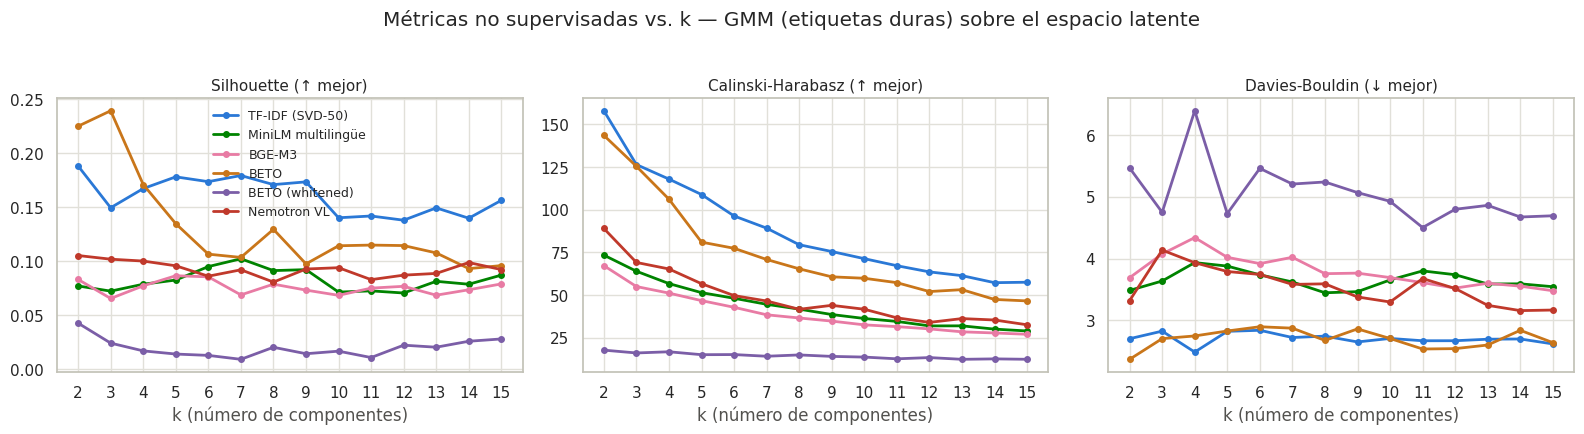

In [14]:
COLORES_TEC = dict(zip(X_gmm, PALETA))
config_metricas = [("silhouette", "Silhouette (↑ mejor)"),
                   ("calinski_harabasz", "Calinski-Harabasz (↑ mejor)"),
                   ("davies_bouldin", "Davies-Bouldin (↓ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (col, titulo) in zip(axes, config_metricas):
    for nombre in X_gmm:
        serie = metricas[metricas["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de componentes)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas no supervisadas vs. k — GMM (etiquetas duras) sobre el espacio latente", y=1.03)
plt.tight_layout()
plt.show()


## Resumen: mejor k por técnica

Se elige el k que maximiza silhouette — el mismo criterio que en los notebooks HC, para
comparar cortes equivalentes — y se reporta junto al **k óptimo por BIC**, el criterio
nativo de la GMM. Si difieren mucho conviene recordar qué mide cada uno: el BIC premia
el mejor modelo de **densidad** (puede preferir más componentes para cubrir una nube
alargada), mientras que silhouette premia la **separación** de la partición dura.


In [15]:
mejores = (metricas.loc[metricas.groupby("tecnica")["silhouette"].idxmax()]
           .set_index("tecnica").round(3))
mejores["k_bic"] = k_bic
mejores["covarianza"] = cov_optima
mejores


,k,silhouette,calinski_harabasz,davies_bouldin,k_bic,covarianza
tecnica,,,,,,
BETO,3,0.239,125.383,2.704,15,tied
BETO (whitened),2,0.043,17.776,5.468,2,diag
BGE-M3,5,0.087,46.764,4.021,6,diag
MiniLM multilingüe,7,0.102,44.600,3.622,14,tied
Nemotron VL,2,0.105,89.000,3.320,12,tied
TF-IDF (SVD-50),2,0.188,157.913,2.703,15,tied


In [16]:
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    tam = np.bincount(etiquetas_por_k[(nombre, k)])[1:].tolist()
    print(f"{nombre} (k={k}): tamaños de clúster = {sorted(tam, reverse=True)}")


TF-IDF (SVD-50) (k=2): tamaños de clúster = [1103, 409]
MiniLM multilingüe (k=7): tamaños de clúster = [300, 241, 219, 217, 202, 184, 149]
BGE-M3 (k=5): tamaños de clúster = [347, 324, 315, 292, 234]
BETO (k=3): tamaños de clúster = [1028, 268, 216]
BETO (whitened) (k=2): tamaños de clúster = [1361, 151]
Nemotron VL (k=2): tamaños de clúster = [1177, 335]


## Métricas supervisadas por número de clústeres (sección como label)

Se usa la sección del artículo (`seccion`) como etiqueta de referencia externa y se
evalúan los cortes k = 2…15 con ARI, AMI, homogeneidad, completitud y V-measure.
Las secciones son muy granulares (cientos de valores distintos entre periódicos),
por lo que se privilegian las métricas ajustadas por azar (ARI, AMI), que no
premian la mera fragmentación.

In [17]:
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score,
                             completeness_score, homogeneity_score, v_measure_score)

secciones = muestra["seccion"].fillna("(sin sección)").to_numpy()
print(f"Secciones distintas en la submuestra: {pd.Series(secciones).nunique()}")

filas = []
for nombre in X_gmm:
    for k in RANGO_K:
        etiquetas = etiquetas_por_k[(nombre, k)]
        filas.append({
            "tecnica": nombre,
            "k": k,
            "ari": adjusted_rand_score(secciones, etiquetas),
            "ami": adjusted_mutual_info_score(secciones, etiquetas),
            "homogeneidad": homogeneity_score(secciones, etiquetas),
            "completitud": completeness_score(secciones, etiquetas),
            "v_measure": v_measure_score(secciones, etiquetas),
        })

metricas_sup = pd.DataFrame(filas)
metricas_sup.head()

Secciones distintas en la submuestra: 213


,tecnica,k,ari,ami,homogeneidad,completitud,v_measure
0,TF-IDF (SVD-50),2,0.029570,0.116249,0.086269,0.557173,0.149405
1,TF-IDF (SVD-50),3,0.041948,0.167711,0.134977,0.548550,0.216645
2,TF-IDF (SVD-50),4,0.045638,0.177580,0.152072,0.523783,0.235709
3,TF-IDF (SVD-50),5,0.079511,0.191816,0.184248,0.465883,0.264064
4,TF-IDF (SVD-50),6,0.099448,0.209382,0.210854,0.462508,0.289656


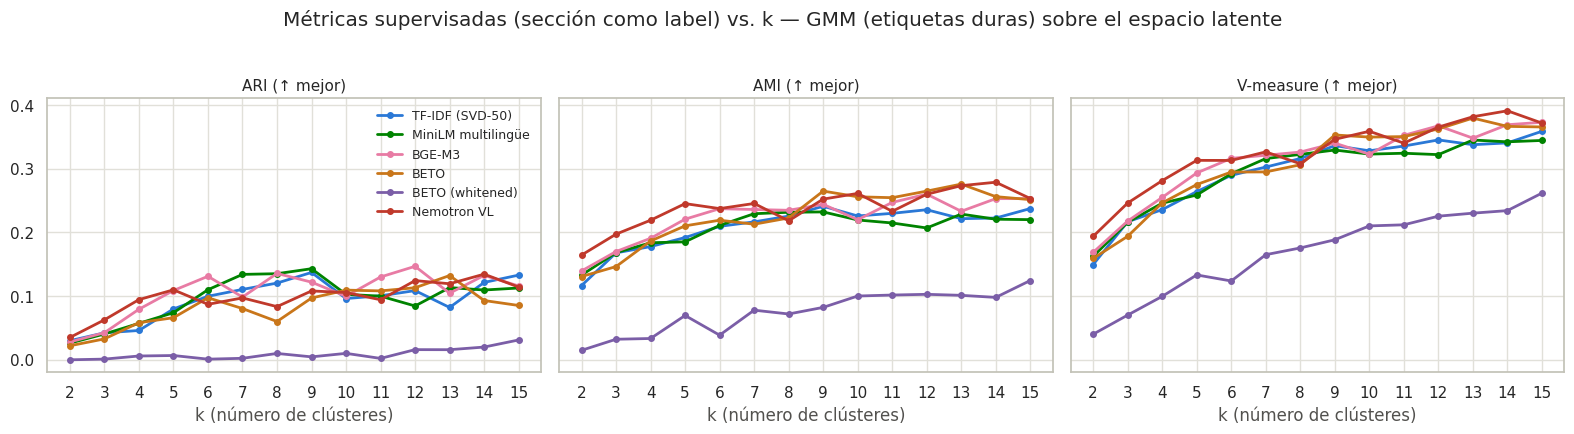

Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:


,k,ari,ami,homogeneidad,completitud,v_measure
tecnica,,,,,,
TF-IDF (SVD-50),2,0.030,0.116,0.086,0.557,0.149
MiniLM multilingüe,7,0.134,0.229,0.239,0.467,0.316
BGE-M3,5,0.108,0.221,0.209,0.492,0.293
BETO,3,0.032,0.146,0.119,0.528,0.194
BETO (whitened),2,-0.000,0.014,0.022,0.251,0.040
Nemotron VL,2,0.035,0.164,0.110,0.787,0.194


In [18]:
config_sup = [("ari", "ARI (↑ mejor)"), ("ami", "AMI (↑ mejor)"),
              ("v_measure", "V-measure (↑ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (col, titulo) in zip(axes, config_sup):
    for nombre in embeddings_lat:
        serie = metricas_sup[metricas_sup["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas supervisadas (sección como label) vs. k — GMM (etiquetas duras) sobre el espacio latente", y=1.03)
plt.tight_layout()
plt.show()

resumen_sup = (metricas_sup.merge(mejores.reset_index()[["tecnica", "k"]].astype({"k": int}),
                                  on=["tecnica", "k"])
               .set_index("tecnica").round(3))
print("Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:")
resumen_sup

## Visualización de los cortes óptimos (t-SNE)

Proyección t-SNE 2D coloreada por la componente GMM (etiqueta dura) en el mejor k de
cada técnica. Los puntos con **aro gris** son los de asignación ambigua (probabilidad
máxima < 0.6): la información que HC no puede dar. Si se concentran en las fronteras
entre nubes, la GMM está capturando exactamente los artículos multi-tema que motivan
este notebook.


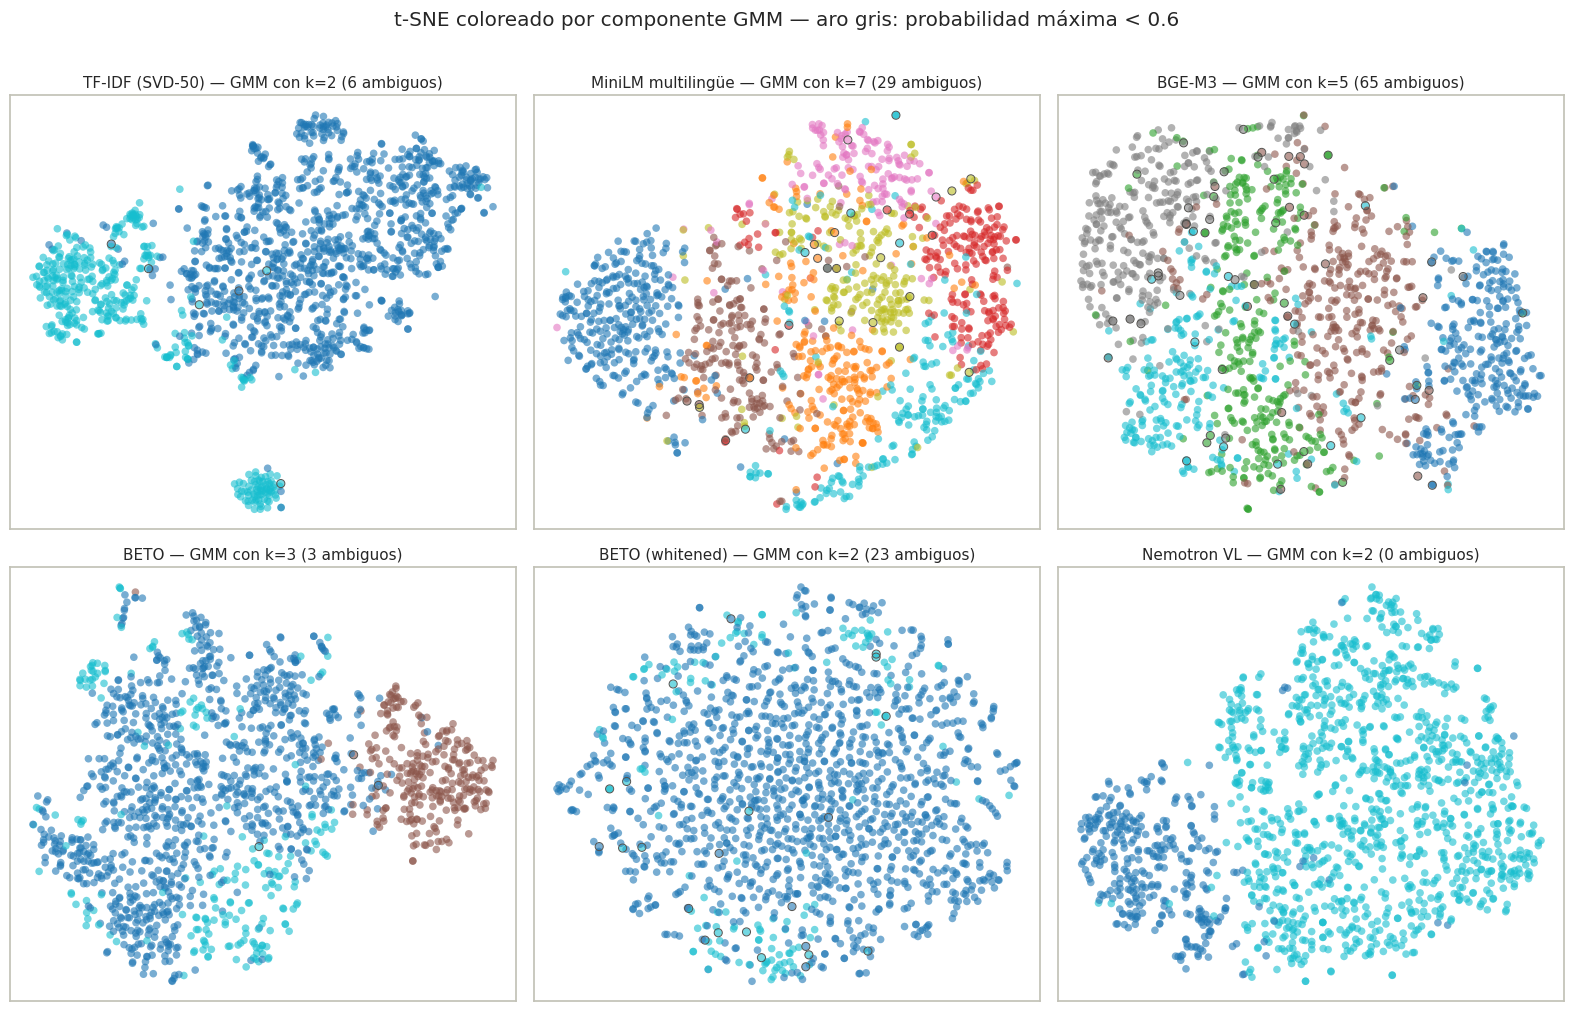

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = rejilla(len(X_gmm), alto=5)
for ax, nombre in zip(axes, X_gmm):
    emb = embeddings_lat[nombre]
    x50 = emb if emb.shape[1] <= 50 else PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(emb)
    xy = TSNE(n_components=2, init="pca", perplexity=30, max_iter=1000,
              random_state=RANDOM_STATE).fit_transform(x50)
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    prob_max = resp_por_k[(nombre, k)].max(axis=1)
    ax.scatter(xy[:, 0], xy[:, 1], c=etiquetas, cmap="tab10", s=30, alpha=0.6, linewidths=0)
    ambiguos = prob_max < 0.6
    ax.scatter(xy[ambiguos, 0], xy[ambiguos, 1], facecolors="none",
               edgecolors="#52514e", s=34, linewidths=0.7)
    ax.set_title(f"{nombre} — GMM con k={k} ({ambiguos.sum()} ambiguos)", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("t-SNE coloreado por componente GMM — aro gris: probabilidad máxima < 0.6", y=1.01)
plt.tight_layout()
plt.show()


## Pertenencias blandas: ¿qué artículos viven entre clústeres?

Esta sección reemplaza al análisis de subclusters de los notebooks HC y es la razón de
usar GMM: cada artículo recibe un vector de probabilidades sobre las k componentes
(responsabilidades), no una etiqueta única. Se resume con tres indicadores en el k
óptimo de cada técnica:

- **prob_max_media** — probabilidad media de la componente ganadora. Cerca de 1, la GMM
  se comporta como una partición dura (tipo k-means) y la ventaja blanda es nula.
- **pct_ambiguos** — porcentaje de artículos cuya **segunda** componente supera
  `UMBRAL_SEGUNDA = 0.25`: artículos genuinamente repartidos entre dos temas.
- **entropia_media** — entropía normalizada media del vector de responsabilidades
  (0 = asignación segura, 1 = repartida uniformemente).


In [20]:
UMBRAL_SEGUNDA = 0.25

filas = []
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    P = resp_por_k[(nombre, k)]
    orden = np.sort(P, axis=1)[:, ::-1]
    entropia = -(P * np.log(np.clip(P, 1e-12, None))).sum(axis=1) / np.log(P.shape[1])
    filas.append({
        "tecnica": nombre,
        "k": k,
        "prob_max_media": orden[:, 0].mean(),
        "pct_ambiguos": (orden[:, 1] > UMBRAL_SEGUNDA).mean() * 100,
        "entropia_media": entropia.mean(),
    })

ambiguedad = pd.DataFrame(filas).set_index("tecnica").round(3)
ambiguedad


,k,prob_max_media,pct_ambiguos,entropia_media
tecnica,,,,
TF-IDF (SVD-50),2,0.989,1.587,0.040
MiniLM multilingüe,7,0.967,3.770,0.047
BGE-M3,5,0.938,8.796,0.099
BETO,3,0.992,0.926,0.019
BETO (whitened),2,0.971,3.902,0.111
Nemotron VL,2,0.999,0.000,0.004


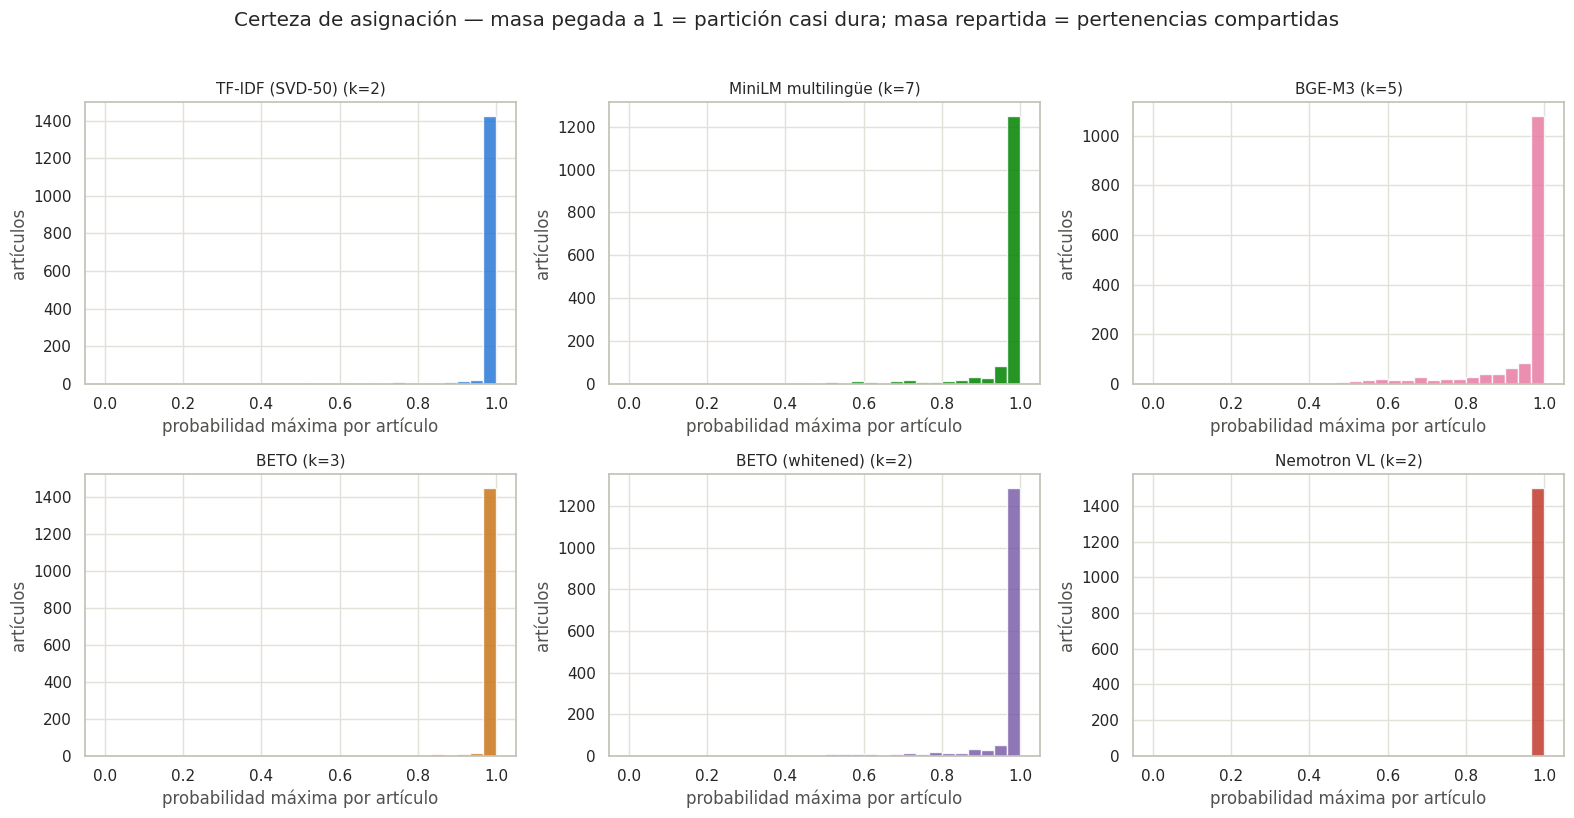

In [21]:
fig, axes = rejilla(len(X_gmm), alto=4.0)
for ax, nombre in zip(axes, X_gmm):
    k = int(mejores.loc[nombre, "k"])
    P = resp_por_k[(nombre, k)]
    ax.hist(P.max(axis=1), bins=30, range=(0, 1), color=COLORES_TEC[nombre], alpha=0.85)
    ax.set_title(f"{nombre} (k={k})", fontsize=11)
    ax.set_xlabel("probabilidad máxima por artículo")
    ax.set_ylabel("artículos")
plt.suptitle("Certeza de asignación — masa pegada a 1 = partición casi dura; "
             "masa repartida = pertenencias compartidas", y=1.02)
plt.tight_layout()
plt.show()


### Artículos de asignación menos segura

Los `N_AMBIGUOS` artículos con menor probabilidad máxima por técnica, con sus dos
componentes más probables. La columna `seccion` permite un primer chequeo manual:
un artículo repartido entre dos componentes cuyos temas son afines (economía/política)
sugiere ambigüedad temática real y no ruido del modelo.


In [22]:
N_AMBIGUOS = 8

tablas = []
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    P = resp_por_k[(nombre, k)]
    top2 = np.argsort(P, axis=1)[:, ::-1][:, :2]
    p1 = P[np.arange(len(P)), top2[:, 0]]
    peores = np.argsort(p1)[:N_AMBIGUOS]  # asignación menos segura
    tablas.append(pd.DataFrame({
        "tecnica": nombre,
        "titulo": muestra.loc[peores, "titulo"].fillna("(sin título)").values,
        "seccion": muestra.loc[peores, "seccion"].values,
        "cluster_1": top2[peores, 0] + 1,
        "p1": p1[peores].round(2),
        "cluster_2": top2[peores, 1] + 1,
        "p2": P[peores, top2[peores, 1]].round(2),
    }))

articulos_ambiguos = pd.concat(tablas, ignore_index=True)
with pd.option_context("display.max_colwidth", 90):
    display(articulos_ambiguos)


,tecnica,titulo,seccion,cluster_1,p1,cluster_2,p2
0,TF-IDF (SVD-50),"11,2",Economía,2,0.51,1,0.49
1,TF-IDF (SVD-50),"Este Es El Menú De Origen By Jorge Rausch, El Primer Restaurante Del Juez De Masterche...",Entretenimiento,2,0.52,1,0.48
2,TF-IDF (SVD-50),"Jorge Delgado Habla De Las ""Dificultades Económicas"" Previo A Los Bolivarianos",Jugada,2,0.52,1,0.48
3,TF-IDF (SVD-50),"Juan Manuel Correa: ""Nunca Volveré A Estar Al 100% Físicamente""",Jugada,1,0.52,2,0.48
4,TF-IDF (SVD-50),"'Blob', Uno De Los Más Grandes Misterios De La Naturaleza, Llega A París",Ciencia Tecnología,1,0.54,2,0.46
5,TF-IDF (SVD-50),Deporte Matinal Con Los Zombies Cyclists,En Ruta,2,0.60,1,0.40
6,TF-IDF (SVD-50),La Realización De La Copa América En Argentina Aún No Está Definida,Jugada,2,0.61,1,0.39
7,TF-IDF (SVD-50),Terceras Elecciones En Israel En Un Año,Mundo,1,0.62,2,0.38
8,MiniLM multilingüe,Intersección Estratégica,Opinión,2,0.35,6,0.34
9,MiniLM multilingüe,"Iglesia Italiana, Bajo Presión Para Autorizar La Indagación De Abusos",Mundo,3,0.42,6,0.35


## Títulos descriptivos por clúster (DeepSeek vía vLLM)

Para cada clúster del corte óptimo se toma una **muestra aleatoria de 10 artículos**
(título + inicio del texto) y se pide a `deepseek-ai/DeepSeek-V4-Flash` (servidor H200,
cliente de `src/llm_clients`) un **título descriptivo corto** del tema dominante.
**Requiere VPN GlobalProtect activa.**

Nota: DeepSeek es un modelo de razonamiento — consume parte del presupuesto de
`max_tokens` en el campo `reasoning` antes de emitir `content`, por eso se usa un
límite generoso aunque la respuesta esperada sea corta.

In [23]:
from src.llm_clients import get_chat_client, load_config

config = load_config()
cliente_chat = get_chat_client(config)
N_EJEMPLOS = 10

PROMPT_TITULO = (
    "Eres un analista de prensa ecuatoriana. A continuación tienes una muestra de "
    "artículos (título y primeras líneas) que pertenecen a un mismo clúster temático "
    "obtenido por clustering no supervisado.\n\n{ejemplos}\n\n"
    "Escribe UN solo título descriptivo en español (máximo 10 palabras) que resuma el "
    "tema dominante del clúster. Si los temas son heterogéneos, dilo en el título "
    "(p. ej. 'Actualidad general: política, deportes y sucesos'). "
    "Responde únicamente con el título, sin comillas ni explicaciones."
)


def titular_cluster(indices: np.ndarray) -> str:
    """Pide a DeepSeek un título descriptivo para los artículos indicados."""
    ejemplos = "\n".join(
        f"- {muestra.loc[i, 'titulo'] or '(sin título)'}: "
        f"{muestra.loc[i, 'texto_norm'][:200]}…"
        for i in indices
    )
    respuesta = cliente_chat.chat.completions.create(
        model=config.chat_model,
        messages=[{"role": "user", "content": PROMPT_TITULO.format(ejemplos=ejemplos)}],
        temperature=0.3,
        max_tokens=2000,  # modelo de razonamiento: reserva presupuesto para 'reasoning'
    )
    contenido = respuesta.choices[0].message.content
    return contenido.strip().strip('"') if contenido else "(respuesta vacía)"


In [24]:
from tqdm.auto import tqdm

rng = np.random.default_rng(RANDOM_STATE)
filas = []
for nombre in X_gmm:
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    for c in tqdm(range(1, k + 1), desc=f"{nombre} (k={k})"):
        indices = np.flatnonzero(etiquetas == c)
        if len(indices) == 0:
            # Con etiquetas duras (argmax) una componente puede quedar sin artículos
            continue
        seleccion = rng.choice(indices, size=min(N_EJEMPLOS, len(indices)), replace=False)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "n_articulos": len(indices),
            "titulo_deepseek": titular_cluster(seleccion),
            "ejemplos": " | ".join(muestra.loc[seleccion[:3], "titulo"].fillna("(sin título)")),
        })

titulos_clusters = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 120):
    display(titulos_clusters)


TF-IDF (SVD-50) (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

MiniLM multilingüe (k=7):   0%|          | 0/7 [00:00<?, ?it/s]

BGE-M3 (k=5):   0%|          | 0/5 [00:00<?, ?it/s]

BETO (k=3):   0%|          | 0/3 [00:00<?, ?it/s]

BETO (whitened) (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

Nemotron VL (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

,tecnica,cluster,n_articulos,titulo_deepseek,ejemplos
0,TF-IDF (SVD-50),1,1103,"Actualidad general: política, ciencia, clima y sucesos",Primer Revés De Pedro Palacios En El Concejo Cantonal De Cuenca | Una Amalgama De Rocas Revela El Real Origen De Mar...
1,TF-IDF (SVD-50),2,409,"Deportes: fútbol, Juegos Olímpicos y polémicas","“Mourinho No Es Racista”, Dice Drogba | 9 De Octubre Vence A U. Católica En El Cierre De La Primera Etapa De Ligapro..."
2,MiniLM multilingüe,1,300,"Noticias deportivas: fútbol, ciclismo y tenis","El Psg Renuncia A Adquirir El Estadio De Francia | “Mourinho No Es Racista”, Dice Drogba | Mar­lon De Jesús des­cen­..."
3,MiniLM multilingüe,2,241,"Actualidad general: clima, política, energía y accidentes",El Cerro Azul De Guayaquil Se Convierte En Bosque Protector Tras Declaratoria Ministerial | Un Tercio De Pakistán Es...
4,MiniLM multilingüe,3,217,"Actualidad ecuatoriana: política, elecciones y corrupción",Las Cinco Revelaciones Más Polémicas Que Destapó La Fiscalía Con El Caso Metástasis | Del Oportunismo Y La Envidia |...
5,MiniLM multilingüe,4,202,"Actualidad general: cultura, deportes y sociedad","Nadal, Cuando El Cuerpo Dice Basta | Misas y ora­cio­nes para los difun­tos | El Arte De 12 Países Se Muestra En 111..."
6,MiniLM multilingüe,5,149,"Actualidad variada: economía, política y sucesos","Quito: Ingreso A Mercados Será De Acuerdo Con El Último Dígito De La Cédula | Sobre El Petróleo | Ford, Soluciones D..."
7,MiniLM multilingüe,6,219,"Actualidad ecuatoriana: salud, educación, economía y más",Ecuador Aseguró Dos Millones De Vacunas De Pfizer Mediante Carta Compromiso | Universidades Ecuatorianas En El ‘Top’...
8,MiniLM multilingüe,7,184,"Actualidad variada: política, violencia y desastres",Trump Dice Que Putin Y Zelenski ‘En Serio’ Piensan En Plan De Paz | Marcha Por El 8M: Analizan Filtración De Grupos ...
9,BGE-M3,1,292,Fútbol ecuatoriano e internacional,"Nueve De Octubre Estará En La Serie A En El 2021; Hace 26 Años Fue La Última Vez | Alemania. Siebert, El Elegido Por..."


### Lectura temática de los artículos ambiguos

Se cruzan los artículos de asignación menos segura con los títulos DeepSeek de sus dos
componentes más probables. Si los pares de temas son afines (p. ej. economía ↔ política),
la ambigüedad es genuina y valida la elección de un modelo blando; si los pares parecen
arbitrarios, la incertidumbre es ruido del ajuste y no estructura temática.


In [25]:
titulos_idx = titulos_clusters.set_index(["tecnica", "cluster"])["titulo_deepseek"]
ambiguos_titulados = articulos_ambiguos.assign(
    tema_1=[titulos_idx.get((t, c), "(componente sin artículos)")
            for t, c in zip(articulos_ambiguos["tecnica"], articulos_ambiguos["cluster_1"])],
    tema_2=[titulos_idx.get((t, c), "(componente sin artículos)")
            for t, c in zip(articulos_ambiguos["tecnica"], articulos_ambiguos["cluster_2"])],
)[["tecnica", "titulo", "p1", "tema_1", "p2", "tema_2"]]
with pd.option_context("display.max_colwidth", 70):
    display(ambiguos_titulados)


,tecnica,titulo,p1,tema_1,p2,tema_2
0,TF-IDF (SVD-50),"11,2",0.51,"Deportes: fútbol, Juegos Olímpicos y polémicas",0.49,"Actualidad general: política, ciencia, clima y sucesos"
1,TF-IDF (SVD-50),"Este Es El Menú De Origen By Jorge Rausch, El Primer Restaurante D...",0.52,"Deportes: fútbol, Juegos Olímpicos y polémicas",0.48,"Actualidad general: política, ciencia, clima y sucesos"
2,TF-IDF (SVD-50),"Jorge Delgado Habla De Las ""Dificultades Económicas"" Previo A Los ...",0.52,"Deportes: fútbol, Juegos Olímpicos y polémicas",0.48,"Actualidad general: política, ciencia, clima y sucesos"
3,TF-IDF (SVD-50),"Juan Manuel Correa: ""Nunca Volveré A Estar Al 100% Físicamente""",0.52,"Actualidad general: política, ciencia, clima y sucesos",0.48,"Deportes: fútbol, Juegos Olímpicos y polémicas"
4,TF-IDF (SVD-50),"'Blob', Uno De Los Más Grandes Misterios De La Naturaleza, Llega A...",0.54,"Actualidad general: política, ciencia, clima y sucesos",0.46,"Deportes: fútbol, Juegos Olímpicos y polémicas"
5,TF-IDF (SVD-50),Deporte Matinal Con Los Zombies Cyclists,0.60,"Deportes: fútbol, Juegos Olímpicos y polémicas",0.40,"Actualidad general: política, ciencia, clima y sucesos"
6,TF-IDF (SVD-50),La Realización De La Copa América En Argentina Aún No Está Definida,0.61,"Deportes: fútbol, Juegos Olímpicos y polémicas",0.39,"Actualidad general: política, ciencia, clima y sucesos"
7,TF-IDF (SVD-50),Terceras Elecciones En Israel En Un Año,0.62,"Actualidad general: política, ciencia, clima y sucesos",0.38,"Deportes: fútbol, Juegos Olímpicos y polémicas"
8,MiniLM multilingüe,Intersección Estratégica,0.35,"Actualidad general: clima, política, energía y accidentes",0.34,"Actualidad ecuatoriana: salud, educación, economía y más"
9,MiniLM multilingüe,"Iglesia Italiana, Bajo Presión Para Autorizar La Indagación De Abusos",0.42,"Actualidad ecuatoriana: política, elecciones y corrupción",0.35,"Actualidad ecuatoriana: salud, educación, economía y más"


## Lectura de resultados

- La comparación directa es doble: contra `hc_autoencoder.ipynb` (mismo latente,
  distinto algoritmo) y contra `gmm_clustering.ipynb` (misma GMM, embedding original en
  lugar de latente). Diferencias con el primero se atribuyen al algoritmo; con el
  segundo, a la reducción del autoencoder.
- Sobre los latentes (16–64 dims) la GMM se ajusta sin PCA previa, así que aquí no hay
  el factor de confusión de la reducción intermedia que sí existe en
  `gmm_clustering.ipynb`.
- **k por silhouette vs. k por BIC**: si el BIC pide sistemáticamente más componentes,
  la GMM está modelando la densidad de una misma nube con varias gaussianas (los
  latentes L2-normalizados viven sobre una hiperesfera) — no implica más temas.
- El veredicto sobre la motivación del notebook está en `pct_ambiguos` y en la tabla de
  artículos ambiguos titulada: si la masa de probabilidad máxima está pegada a 1, la GMM
  degenera en partición dura y no aporta nada sobre HC; si hay artículos repartidos
  entre componentes temáticamente afines, el soft clustering captura estructura que HC
  pierde por construcción.
- Calinski-Harabasz no es comparable **entre** técnicas ni contra los valores de los
  otros notebooks (depende de la escala del espacio); úsese solo dentro de una misma
  representación.
